In [1]:
import pandas as pd
import numpy as np

# NLP
from sklearn.feature_extraction.text import TfidfVectorizer

# Clustering
from sklearn.cluster import KMeans

# Visualization
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [3]:
df = pd.read_csv("Major_AI_Projects.csv")
df.head()

,Project_Name,Description,Domain,Year
0,ChatGPT,Conversational AI model for human-like responses,NLP,2022
1,AlphaGo,AI system that defeated Go champions,Reinforcement Learning,2016
2,Tesla Autopilot,Self-driving car system,Computer Vision,2020
3,Google Translate,Language translation system,NLP,2018
4,IBM Watson,AI system for QA and healthcare,NLP,2011


In [4]:
vectorizer = TfidfVectorizer(stop_words='english')

X = vectorizer.fit_transform(df['Description'])

In [5]:
k = 3  # number of clusters
kmeans = KMeans(n_clusters=k, random_state=42)

df['Cluster'] = kmeans.fit_predict(X)

In [6]:
df[['Project_Name', 'Domain', 'Cluster']]

,Project_Name,Domain,Cluster
0,ChatGPT,NLP,2
1,AlphaGo,Reinforcement Learning,2
2,Tesla Autopilot,Computer Vision,0
3,Google Translate,NLP,0
4,IBM Watson,NLP,2
5,DALL-E,Generative AI,0
6,Midjourney,Generative AI,2
7,DeepMind AlphaFold,BioAI,0
8,Siri,NLP,1
9,Alexa,NLP,1


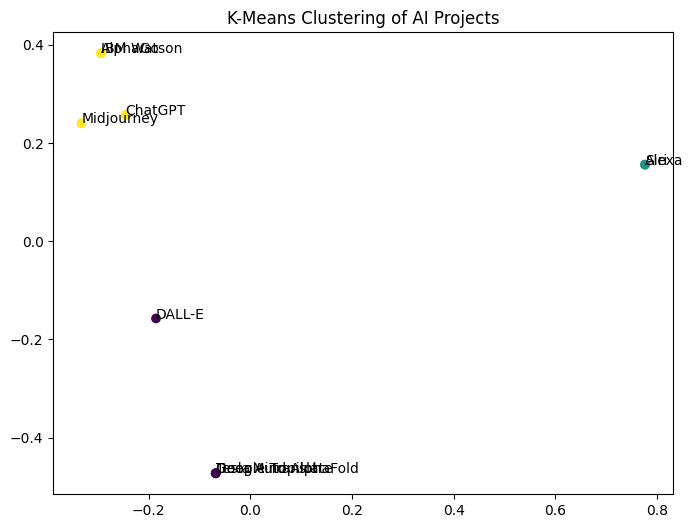

In [7]:
pca = PCA(n_components=2)
reduced = pca.fit_transform(X.toarray())

plt.figure(figsize=(8,6))
plt.scatter(reduced[:,0], reduced[:,1], c=df['Cluster'], cmap='viridis')

for i, txt in enumerate(df['Project_Name']):
    plt.annotate(txt, (reduced[i,0], reduced[i,1]))

plt.title("K-Means Clustering of AI Projects")
plt.show()

In [8]:
terms = vectorizer.get_feature_names_out()

for i in range(k):
    center = kmeans.cluster_centers_[i]
    top_words = [terms[ind] for ind in center.argsort()[-5:]]
    print(f"Cluster {i}: {top_words}")

Cluster 0: ['driving', 'car', 'protein', 'language', 'translation']
Cluster 1: ['human', 'home', 'smart', 'assistant', 'voice']
Cluster 2: ['champions', 'healthcare', 'defeated', 'qa', 'ai']
